# Analysis of water potability

## Analysis objective

The objective of this analysis is to explore a water potability dataset and build a basic machine learning workflow to predict whether a water sample is potable based on its physicochemical characteristics. The project focuses on assessing data quality, handling missing values, performing exploratory data analysis, and comparing different classification models, including logistic regression and random forest.

In addition, this analysis evaluates how different missing-value treatment strategies, such as KNN imputation and complete-case analysis, affect model performance. Model results are compared using accuracy, ROC-AUC, precision, and recall, with particular attention to the model’s ability to identify potable water samples.

## Introduction

The original dataset, `water_potability.csv`, contains 3,276 water samples and 10 columns. Each sample includes several physicochemical water-quality indicators, such as pH, hardness, dissolved solids, chloramines, sulfate, conductivity, organic carbon, trihalomethanes, and turbidity. The target variable is `Potability`, which indicates whether the water is safe for drinking.

The meanings of each column in `water_potability.csv` are as follows:

- `pH`: The pH value of the water sample, indicating how acidic or alkaline the water is.
- `Hardness`: The hardness level of the water, mainly related to dissolved calcium and magnesium.
- `Solids`: The amount of total dissolved solids in the water.
- `Chloramines`: The amount of chloramines in the water, which are commonly used as disinfectants.
- `Sulfate`: The concentration of sulfate dissolved in the water.
- `Conductivity`: The electrical conductivity of the water, which reflects the concentration of dissolved ions.
- `Organic_carbon`: The amount of organic carbon present in the water.
- `Trihalomethanes`: The concentration of trihalomethanes, which may form during water disinfection.
- `Turbidity`: The turbidity level of the water, indicating how clear or cloudy the water is.
- `Potability`: The target variable. A value of 1 indicates potable water, while a value of 0 indicates non-potable water.

## Load data

Import the required libraries for data analysis and use Pandas' `read_csv()` function to load the raw `water_potability.csv` file into a DataFrame named `original_water_data`.

In [1]:
import pandas as pd

In [2]:
original_water_data = pd.read_csv('./water_potability.csv')
original_water_data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


## Data evaluation and cleaning

### Back up original data

In [3]:
cleaned_water_data = original_water_data.copy()

### Data tidiness

In [4]:
cleaned_water_data.sample(10)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
269,9.058628,155.357557,15737.468938,7.251979,343.233977,463.389256,17.854470,83.175189,3.652134,1
625,7.648878,188.506977,22510.975070,8.617208,NaN,393.293539,12.854519,73.313503,4.953534,0
1171,6.043360,188.662329,24856.607107,4.371025,295.895207,355.007461,7.619812,79.944916,4.745248,1
30,7.181449,209.625601,15196.229987,5.994679,338.336431,342.111286,7.922598,71.537953,5.088860,0
2276,7.094802,222.501306,30045.367741,6.664010,NaN,531.959462,16.162941,46.100959,4.084660,0
2124,5.098967,197.142637,21682.754771,7.755905,292.251426,424.666112,10.927590,51.220960,4.333667,0
1545,8.370365,155.553565,27193.317378,5.791453,NaN,356.519865,7.832108,69.419665,2.746650,1
1380,6.710634,203.642917,23748.183992,6.726664,342.441433,455.967558,15.879549,63.676952,3.863287,0
2919,6.898932,209.636422,15422.220893,6.884918,293.562020,396.811214,15.671717,66.597336,3.688456,0
2999,4.618851,199.318913,27174.687638,7.218588,371.056861,312.281382,14.040787,NaN,4.322116,0


In [5]:
cleaned_water_data = cleaned_water_data.rename(columns={'ph':'pH'})
cleaned_water_data

,pH,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


From a random sample of 10 rows, each column represents a variable, each row represents an observation, and each cell contains a single value. Therefore, after rearranging the column name of `pH`, the dataset is tidy. 

### Data quality

In [6]:
cleaned_water_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pH               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


The dataset contains 3276 rows and 10 columns. Columns of `pH`, `Sulfate`, and `Trihalomethanes` contain missing values. All data types are reasonable for the analysis objective, so there is no need for dtype conversion.

#### Missing data

In [7]:
cleaned_water_data.isna().sum()

pH                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Missing values are found in three columns: `pH`, `Sulfate`, and `Trihalomethanes`. `Sulfate` has the most missing values, while `Trihalomethanes` has relatively fewer missing values. No missing values are found in the target variable `Potability`, so the classification labels are complete.

Because the missing data only appear in feature columns, missing-value handling is required before model training. Two approaches will be compared in this project: KNN imputation and complete-case analysis.

#### Duplicated data

In [8]:
cleaned_water_data.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset.

#### Inconsistent data

The target variable `Potability` was checked to ensure that it only contained binary values, 0 and 1. 

In [9]:
cleaned_water_data['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

No invalid class labels were found.

#### Invalid or erroneous data

In [10]:
cleaned_water_data.describe()

,pH,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


The descriptive statistics were reviewed to identify potential invalid or erroneous numerical values. For the `pH` column, values should generally fall within the range of 0 to 14. The minimum and maximum pH values in this dataset are 0 and 14, respectively, so no pH values fall outside the valid range.

No clearly invalid numerical values were identified based on this summary check.

## Data visualization

This section uses visualizations to better understand the dataset, including feature distributions, target class balance, and relationships among water-quality variables.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

Related libraries are imported for data visualization. `matplotlib` is used for basic plot customization, while `seaborn` is used to create clearer statistical visualizations.

In [12]:
sns.set_palette("Set2")

Use the `Set2` color palette to make the visualizations clearer and more visually consistent.

### Target variable distribution

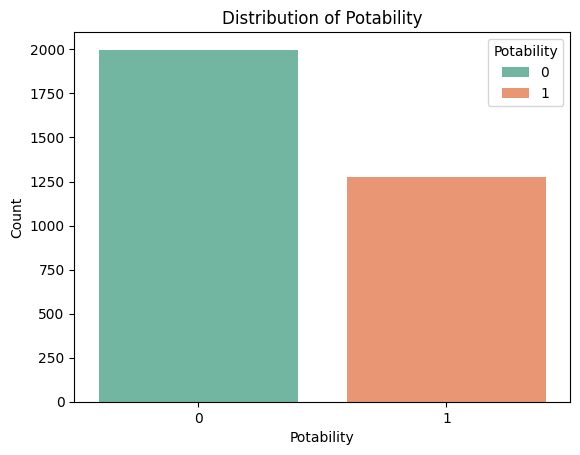

In [13]:
sns.countplot(data=cleaned_water_data, x='Potability', hue = 'Potability')
plt.title('Distribution of Potability')
plt.xlabel('Potability')
plt.ylabel('Count')
plt.show()

The plot shows the distribution of the target variable `Potability`. The dataset contains more non-potable water samples (`0`) than potable water samples (`1`), indicating that the two classes are not perfectly balanced.

### Feature distributions

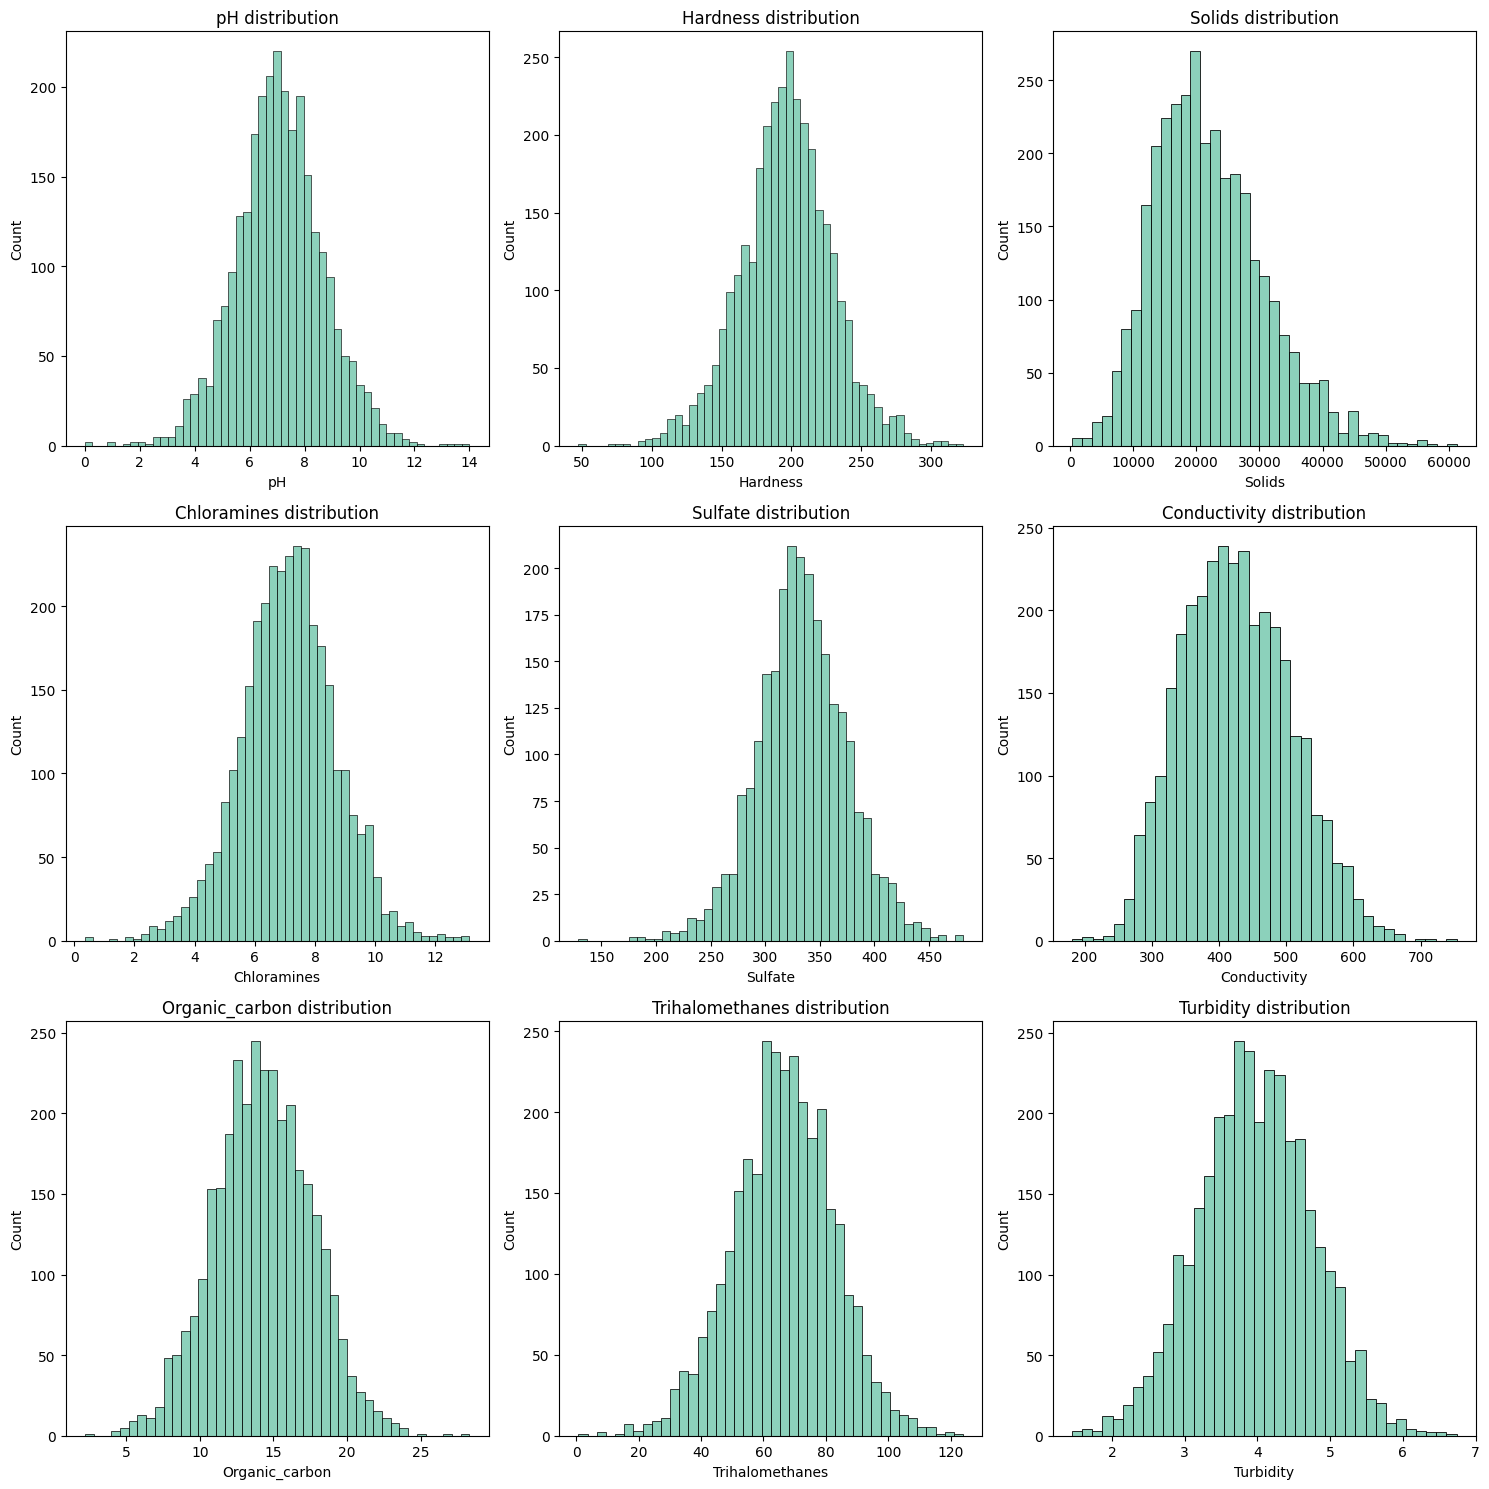

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, col in enumerate(cleaned_water_data.drop(columns = 'Potability').columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data = cleaned_water_data, x = col)
    plt.title(f'{col} distribution')

plt.tight_layout()
plt.show()

The histograms show the distributions of the numerical water-quality features. Most variables, such as `pH`, `Hardness`, `Chloramines`, `Sulfate`, `Conductivity`, `Organic_carbon`, `Trihalomethanes`, and `Turbidity`, are roughly centered around their average values with moderate spread.

`Solids` appears to be more right-skewed than the other variables, meaning that most samples have relatively lower dissolved solid levels, while a smaller number of samples have much higher values.

These plots provide an initial understanding of the feature distributions before comparing them with the target variable `Potability`.

### Feature distributions by Potability

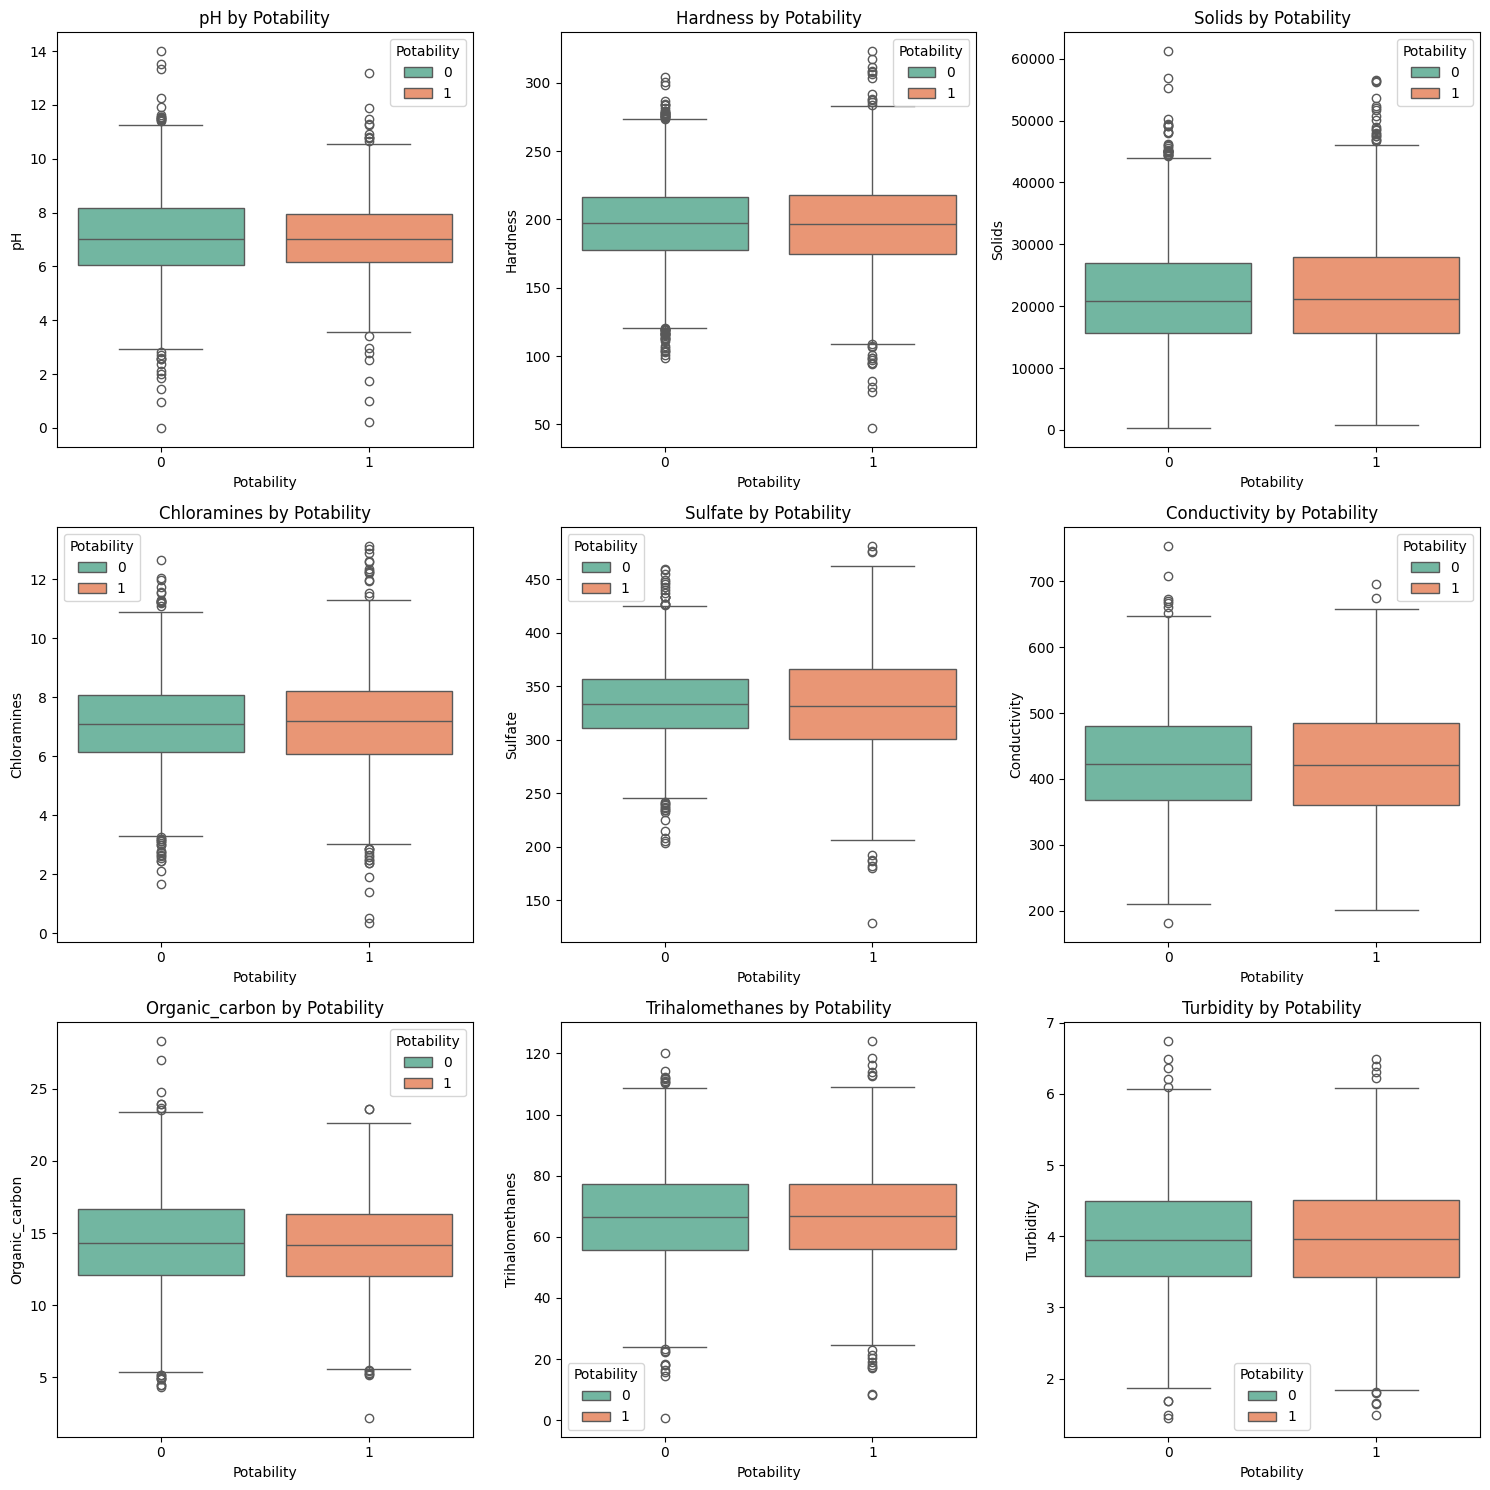

In [15]:
plt.figure(figsize=(15, 15))

for i, col in enumerate(cleaned_water_data.drop(columns = 'Potability').columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data = cleaned_water_data, x = 'Potability', y = col, hue = 'Potability')
    plt.title(f'{col} by Potability')

plt.tight_layout()
plt.show()

The boxplots compare the distributions of each water-quality feature between non-potable water samples (`0`) and potable water samples (`1`). For most features, the median values and interquartile ranges are fairly similar between the two groups, suggesting that no single feature shows a strong visual separation between potable and non-potable samples.

Visible outliers appear in all feature plots for both classes. These outliers may reflect variation in water-quality measurements rather than obvious data errors, so they are kept in the dataset at this stage.
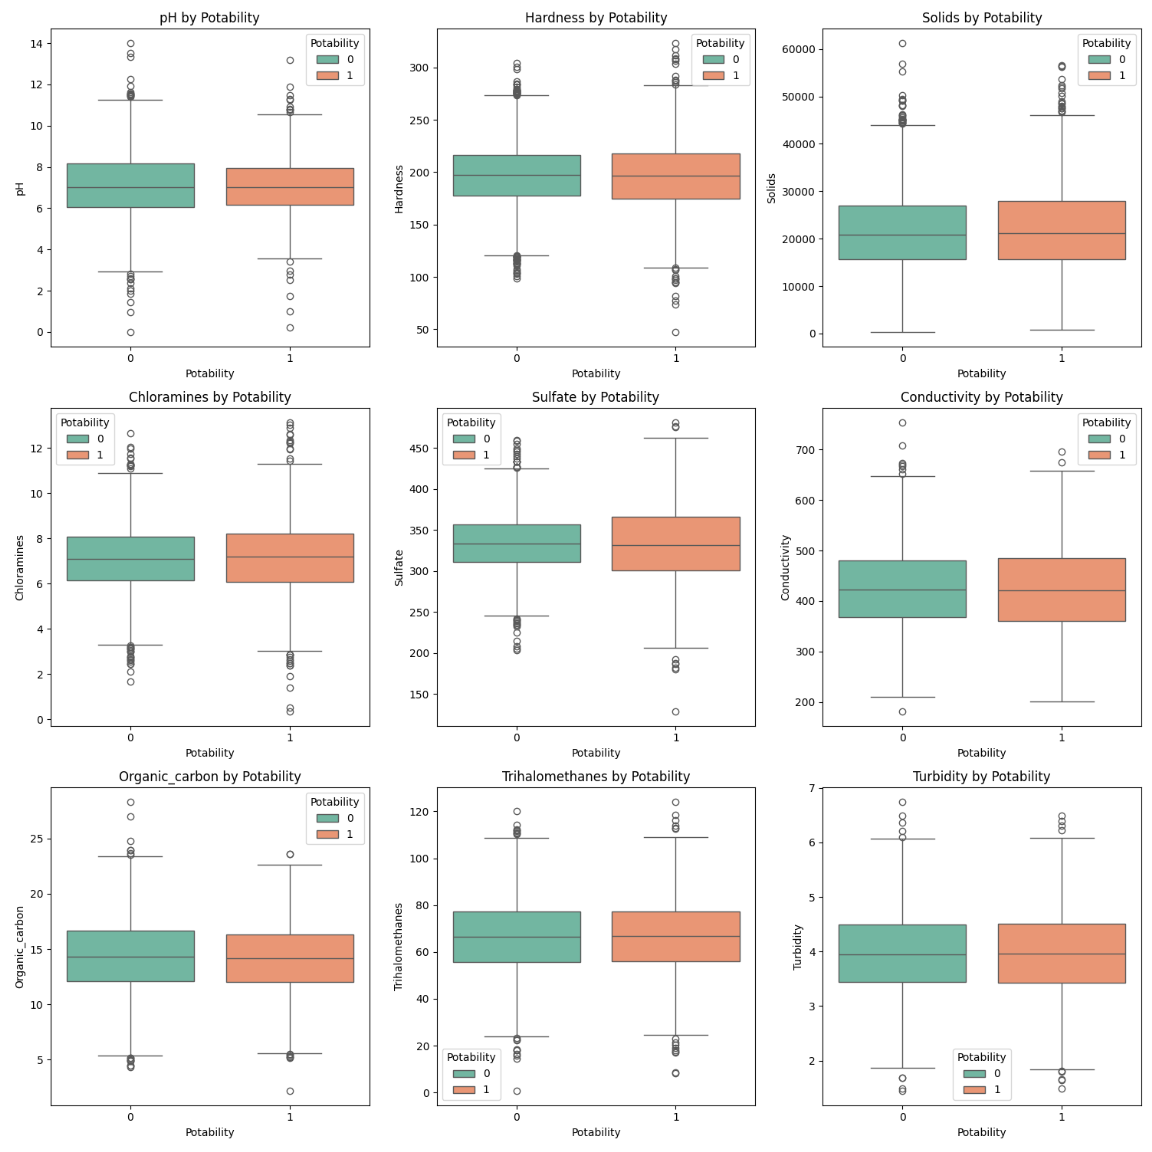

### Correlation heatmap

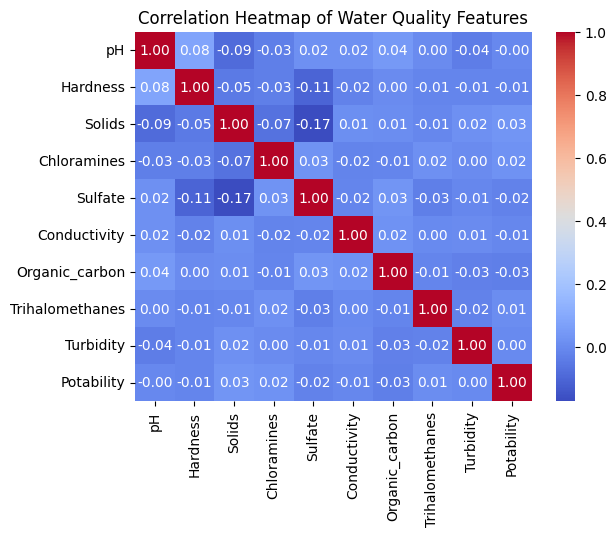

In [16]:
sns.heatmap(cleaned_water_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Water Quality Features')
plt.show()

Most water-quality features show very weak linear correlations with each other, suggesting that strong multicollinearity is not a major concern in this dataset. The strongest visible relationship is between `Solids` and `Sulfate`, but the correlation is still low at around -0.17.

The correlations between the feature variables and `Potability` are also close to zero. This suggests that no single feature has a strong linear relationship with the target variable, so more flexible models may be needed to capture possible non-linear patterns.

## Data analysis

### Data preparation

#### Data processing libraries

In [17]:
import numpy as np
import pandas as pd

`numpy` and `pandas` are imported for numerical operations, data loading, data cleaning, and dataset manipulation.

#### Machine learning tools

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

The following scikit-learn tools are imported for splitting the dataset, handling missing values, scaling numerical features, and training classification models.

#### Model evaluation metrics

In [19]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
)

The following metrics are imported to evaluate model performance from different perspectives, including overall accuracy, probability-based discrimination, and class-level prediction performance.

Store all model evaluation results.

In [20]:
results = []

### Define evaluation function

In [21]:
def evaluate_model(method_name, model_name, y_true, y_pred, y_prob):
    return {
        'Missing Data Method': method_name,
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'Precision Class 1': precision_score(y_true, y_pred, pos_label = 1, zero_division = 0),
        'Recall Class 1': recall_score(y_true, y_pred, pos_label = 1, zero_division = 0),
        'Recall Class 0': recall_score(y_true, y_pred, pos_label = 0, zero_division = 0)
    }

This function is created to evaluate all models using the same set of metrics. It takes the missing-data handling method, model name, true labels, predicted labels, and predicted probabilities as inputs, then returns the model performance results in a dictionary.

The returned results include accuracy, ROC-AUC, precision for potable water samples, and recall for both potable and non-potable water samples. This makes it easier to compare different models and missing-value handling methods later in the analysis.

### Method 1: KNN imputation

In this method, missing values are handled using KNN imputation. The dataset is first split into training and testing sets before imputation to avoid using information from the test set during preprocessing.

In [22]:
X = cleaned_water_data.drop(columns = 'Potability')
y = cleaned_water_data['Potability']

The feature variables are separated from the target variable. `X` contains the water-quality indicators used for prediction, while `y` contains the target variable `Potability`.

In [23]:
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

The dataset is split into training and testing sets before applying KNN imputation and model training. This prevents the imputer and models from learning information from the test set. The `stratify = y` parameter keeps the class distribution of `Potability` similar in both sets.

#### Baseline

In [24]:
majority_class_knn = y_train_knn.mode()[0]
y_pred_baseline_knn = np.full(shape = len(y_test_knn), fill_value = majority_class_knn)
y_prob_baseline_knn = np.full(shape = len(y_test_knn), fill_value = y_train_knn.mean())

Store model evaluation results.

In [25]:
results.append(evaluate_model(
    method_name='KNN Imputation',
    model_name='Baseline',
    y_true=y_test_knn,
    y_pred=y_pred_baseline_knn,
    y_prob=y_prob_baseline_knn
))

A majority-class baseline model is created before training machine learning models. This baseline uses only the target labels in the training set and always predicts the most common class.

Since the baseline does not use any water-quality features, it does not require KNN imputation. Its result is stored as a simple reference point for comparing the logistic regression and random forest models later.

#### Imputation

Scale the data before KNN imputation. This helps KNN compare samples fairly because different features have different value ranges

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_knn)
X_test_scaled = scaler.transform(X_test_knn)

Apply KNN imputation on the scaled data. The imputer learns from the training set only, then applies the same rule to the test set.

In [27]:
imputer = KNNImputer(n_neighbors = 5)
X_train_imputed_scaled = imputer.fit_transform(X_train_scaled)
X_test_imputed_scaled = imputer.transform(X_test_scaled)

Convert the imputed data back to the original feature scale. After this step, the feature values are back to their original units.

In [28]:
X_train_imputed = pd.DataFrame(
    scaler.inverse_transform(X_train_imputed_scaled),
    columns = X_train_knn.columns,
    index = X_train_knn.index
)

X_test_imputed = pd.DataFrame(
    scaler.inverse_transform(X_test_imputed_scaled),
    columns = X_test_knn.columns,
    index = X_test_knn.index
)

In [29]:
print(X_train_imputed.isna().sum())
print(X_test_imputed.isna().sum())

pH                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64
pH                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64


#### Logistic regression

Train logistic regression using the imputed data in the original feature scale.

In [30]:
logistic_knn = LogisticRegression(max_iter = 5000)
logistic_knn.fit(X_train_imputed, y_train_knn)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Generate predicted labels and predicted probabilities for the test set.

In [31]:
y_pred_logistic_knn = logistic_knn.predict(X_test_imputed)
y_prob_logistic_knn = logistic_knn.predict_proba(X_test_imputed)[:, 1]

Store model evaluation results.

In [32]:
results.append(evaluate_model(
    method_name = 'KNN Imputation',
    model_name = 'Logistic Regression',
    y_true = y_test_knn,
    y_pred = y_pred_logistic_knn,
    y_prob = y_prob_logistic_knn
))

Create a coefficient table for logistic regression.

In [33]:
logistic_coef_table = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Coefficient': logistic_knn.coef_[0],
    'Odds Ratio': np.exp(logistic_knn.coef_[0])
})
logistic_coef_table

,Feature,Coefficient,Odds Ratio
0,pH,0.018994,1.019176
1,Hardness,-0.000207,0.999793
2,Solids,0.000007,1.000007
3,Chloramines,0.026447,1.026800
4,Sulfate,-0.000742,0.999258
5,Conductivity,0.000058,1.000058
6,Organic_carbon,-0.008942,0.991098
7,Trihalomethanes,0.000470,1.000470
8,Turbidity,0.003160,1.003165


The logistic regression model is trained after KNN imputation. Before applying KNN imputation, the features are standardized so that variables with larger numerical ranges do not dominate the distance calculation. After imputation, the data are converted back to the original feature scale using `inverse_transform`.

The coefficient table is therefore based on the original feature units. Each coefficient represents the change in log-odds of potable water for a one-unit increase in the corresponding feature, while the odds ratio shows the multiplicative change in odds.

Most odds ratios are close to 1, suggesting that individual features have relatively weak linear effects in this logistic regression model. Since the features have very different original units and value ranges, the coefficient magnitudes should not be directly compared across variables.

#### Random forest

Train random forest using the same KNN-imputed data in the original feature scale.

In [34]:
rf_knn = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_knn.fit(X_train_imputed, y_train_knn)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Generate predicted labels and predicted probabilities for the test set.

In [35]:
y_pred_rf_knn = rf_knn.predict(X_test_imputed)
y_prob_rf_knn = rf_knn.predict_proba(X_test_imputed)[:, 1]

Store model evaluation results.

In [36]:
results.append(evaluate_model(
    method_name = 'KNN Imputation',
    model_name ='Random Forest',
    y_true = y_test_knn,
    y_pred = y_pred_rf_knn,
    y_prob = y_prob_rf_knn
))

The random forest model is trained using the same KNN-imputed dataset as the logistic regression model. Since the missing values have already been imputed and the data have been converted back to the original feature scale, no additional scaling or imputation is applied in this step.

The model is trained on the imputed training set and then used to generate predicted labels and predicted probabilities for the test set.

### Method 2: Drop missing rows

Rows containing any missing values are removed to create the complete-case dataset.

In [37]:
complete_case_data = cleaned_water_data.dropna().reset_index(drop = True)
print("Original data shape:", cleaned_water_data.shape)
print("Complete-case data shape:", complete_case_data.shape)

Original data shape: (3276, 10)
Complete-case data shape: (2011, 10)


The class distribution is checked after removing missing values.

In [38]:
complete_case_data['Potability'].value_counts(normalize = True)

Potability
0    0.596718
1    0.403282
Name: proportion, dtype: float64

#### Prepare complete-case data

In this method, rows containing missing values have already been removed. The complete-case dataset is then separated into feature variables and the target variable. `X_complete` contains the water-quality indicators, while `y_complete` contains the target variable `Potability`.

In [39]:
X_complete = complete_case_data.drop(columns = 'Potability')
y_complete = complete_case_data['Potability']

The complete-case dataset is split into training and testing sets using the same test size and random state as the KNN imputation method. The `stratify = y_complete` parameter is used to keep the class distribution similar in both sets.

In [40]:
X_train_complete, X_test_complete, y_train_complete, y_test_complete = train_test_split(
    X_complete, y_complete, test_size = 0.2, random_state = 42, stratify = y_complete
)

#### Baseline

In [41]:
majority_class_complete = y_train_complete.mode()[0]
y_pred_baseline_complete = np.full(shape = len(y_test_complete), fill_value = majority_class_complete)
y_prob_baseline_complete = np.full(shape = len(y_test_complete), fill_value = y_train_complete.mean())

Store model evaluation results.

In [42]:
results.append(evaluate_model(
    method_name = 'Complete-case Analysis',
    model_name = 'Baseline',
    y_true = y_test_complete,
    y_pred = y_pred_baseline_complete,
    y_prob = y_prob_baseline_complete
))

A majority-class baseline model is created for the complete-case dataset. This baseline always predicts the most common class in the complete-case training set and does not use any feature variables.

The baseline provides a simple reference point for evaluating whether the logistic regression and random forest models perform better than a default majority-class prediction.

#### Logistic regression

Train logistic regression using complete-case data in the original feature scale.

In [43]:
logistic_complete = LogisticRegression(max_iter=5000)
logistic_complete.fit(X_train_complete, y_train_complete)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Generate predicted labels and predicted probabilities for the test set.

In [44]:
y_pred_logistic_complete = logistic_complete.predict(X_test_complete)
y_prob_logistic_complete = logistic_complete.predict_proba(X_test_complete)[:, 1]

Store model evaluation results.

In [45]:
results.append(evaluate_model(
    method_name = 'Complete-case Analysis',
    model_name = 'Logistic Regression',
    y_true = y_test_complete,
    y_pred = y_pred_logistic_complete,
    y_prob = y_prob_logistic_complete
))

Create a coefficient table for logistic regression.

In [46]:
logistic_complete_coef_table = pd.DataFrame({
    'Feature': X_train_complete.columns,
    'Coefficient': logistic_complete.coef_[0],
    'Odds Ratio': np.exp(logistic_complete.coef_[0])
})

logistic_complete_coef_table

,Feature,Coefficient,Odds Ratio
0,pH,0.024302,1.024599
1,Hardness,-0.000445,0.999555
2,Solids,0.000010,1.000010
3,Chloramines,0.022525,1.022780
4,Sulfate,-0.001063,0.998938
5,Conductivity,-0.000801,0.999200
6,Organic_carbon,0.007771,1.007802
7,Trihalomethanes,0.000231,1.000231
8,Turbidity,0.044203,1.045195


The logistic regression model is trained directly on the complete-case data without feature scaling. Since rows with missing values have already been removed, no imputation is needed. The coefficients are therefore based on the original feature units.

#### Random forest

In [47]:
rf_complete = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_complete.fit(X_train_complete, y_train_complete)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
y_pred_rf_complete = rf_complete.predict(X_test_complete)
y_prob_rf_complete = rf_complete.predict_proba(X_test_complete)[:, 1]

In [49]:
results.append(evaluate_model(
    method_name = 'Complete-case Analysis',
    model_name ='Random Forest',
    y_true = y_test_complete,
    y_pred = y_pred_rf_complete,
    y_prob = y_prob_rf_complete
))

The random forest model is trained using the complete-case dataset, where rows with missing values have already been removed. Since random forest does not require feature scaling, the model is trained directly on the original feature values.

After training, the model is used to generate predicted labels and predicted probabilities for the test set. The evaluation results are stored and later compared with the baseline and logistic regression models.

## Model comparison

In [50]:
model_comparison = pd.DataFrame(results)
model_comparison

,Missing Data Method,Model,Accuracy,ROC-AUC,Precision Class 1,Recall Class 1,Recall Class 0
0,KNN Imputation,Baseline,0.609756,0.500000,0.000000,0.000000,1.000000
1,KNN Imputation,Logistic Regression,0.609756,0.552549,0.000000,0.000000,1.000000
2,KNN Imputation,Random Forest,0.658537,0.655957,0.640351,0.285156,0.897500
3,Complete-case Analysis,Baseline,0.595533,0.500000,0.000000,0.000000,1.000000
4,Complete-case Analysis,Logistic Regression,0.595533,0.509611,0.500000,0.006135,0.995833
5,Complete-case Analysis,Random Forest,0.692308,0.741564,0.724138,0.386503,0.900000


The model comparison table shows that the baseline models mainly predict the majority class, which is non-potable water (`0`). This explains why both baseline models have moderate accuracy but a recall of 0 for class `1`, meaning they do not identify any potable water samples.

Logistic regression performs similarly to the baseline under both missing-value handling methods. Its recall for class `1` remains very low, suggesting that a simple linear model does not capture enough useful patterns to distinguish potable and non-potable water samples.

Random forest performs better than logistic regression in both methods. Under KNN imputation, the random forest model improves ROC-AUC to about 0.656 and achieves a class `1` recall of about 0.285. Under complete-case analysis, the random forest model gives the best results, with the highest accuracy of about 0.692 and the highest ROC-AUC of about 0.742.

The complete-case random forest model shows the strongest performance in this comparison. However, its recall for class `1` is still below 0.4, meaning that many potable water samples are still not correctly identified. This suggests that further model tuning or additional feature engineering may be needed to improve the classification of potable water samples.

## Conclusion

This project built an exploratory classification workflow to predict water potability using water-quality features. The analysis compared two missing-value handling methods and evaluated baseline, logistic regression, and random forest models.

The results suggest that water potability is not easily separated by a simple linear model, while random forest provides better classification performance. However, the model still has limited ability to identify all potable water samples, so the results should be interpreted as exploratory rather than ready for practical decision-making.

Future improvements could include threshold adjustment, hyperparameter tuning, feature engineering, and testing additional classification models.